In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)

from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun
from utils.Plotter import Plotter as plotterfun
from utils.general_stats import GeneralStats



In [2]:
data_handler = datafun(data=None)  # Pass any initial data if needed

info_dir = 'W:\Connie/results\Bassi2025\data'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)

#remove datasets for now while some are still running - finished: 0,1,2,3,4,5,6,7,11,14 
# Indices to remove (example: remove datasets at indices 0 and 2)
remove_indices = list(set(range(0,25)) - set([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23])) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #[2,3,8,18]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]


model_type = 'GLM_3nmf_pre'
results_pre = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[0,5]) 
model_type = 'GLM_3nmf_passive'
results_pass = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[0,5])
#5MIN TO LOAD PRE AND PASSIVE 20 DATASETS

dir = os.path.join('W:\Connie/results\Bassi2025\data')
#load significant sound/opto neurons
opto, sound, mouse_dates, significant_neurons, mod_indices = data_handler.load_sound_opto_data(dir, set_diff = True, exclude = "HE1-00_2023-05-30")

Processing dataset: HA11-1R_2023-05-05
poss_model_0_data_cluster_0.pkl
poss_model_0_data_cluster_1.pkl
poss_model_0_data_cluster_2.pkl
poss_model_0_data_cluster_3.pkl
poss_model_0_data_cluster_4.pkl
poss_model_0_data_cluster_5.pkl
poss_model_0_data_cluster_6.pkl
poss_model_0_data_cluster_7.pkl
poss_model_0_data_cluster_8.pkl
poss_model_0_data_cluster_9.pkl
poss_model_0_data_cluster_10.pkl
poss_model_0_data_cluster_11.pkl
poss_model_0_data_cluster_12.pkl
poss_model_0_data_cluster_13.pkl
poss_model_0_data_cluster_14.pkl
poss_model_0_data_cluster_15.pkl
poss_model_0_data_cluster_16.pkl
poss_model_0_data_cluster_17.pkl
poss_model_0_data_cluster_18.pkl
poss_model_0_data_cluster_19.pkl
poss_model_0_data_cluster_20.pkl
poss_model_0_data_cluster_21.pkl
poss_model_0_data_cluster_22.pkl
poss_model_0_data_cluster_23.pkl
poss_model_0_data_cluster_24.pkl
poss_model_0_data_cluster_25.pkl
poss_model_0_data_cluster_26.pkl
poss_model_0_data_cluster_27.pkl
poss_model_0_data_cluster_28.pkl
poss_model_0_d

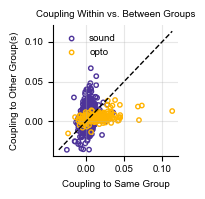

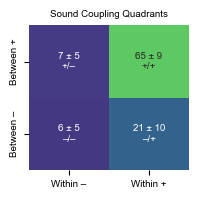

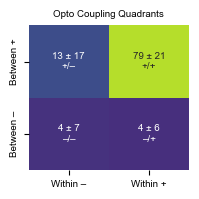

Chi-square test between sound and opto:
  χ² = 60.24, p = 5.219e-13, dof = 3
  Contingency Table:
       +/–   +/+  –/–  –/+
sound  112  1312   96  472
opto    27   214   10   10
Permutation test p-value: 0, observed stat: 0.396


c:\Users\runyan1\AppData\Local\anaconda3\envs\Python_GLM\Lib\site-packages\scipy\stats\_resampling.py:1114: RuntimeWarning: overflow encountered in double_scalars
  n_max = factorial(n_obs_sample)**n_samples


sound: p=0.0142, stat=0.000
opto: p=0.0002, stat=0.008
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling


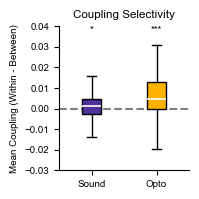

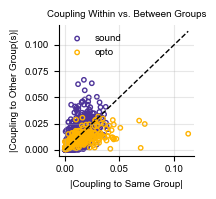

c:\Users\runyan1\AppData\Local\anaconda3\envs\Python_GLM\Lib\site-packages\scipy\stats\_resampling.py:1114: RuntimeWarning: overflow encountered in double_scalars
  n_max = factorial(n_obs_sample)**n_samples


sound: p=0.0002, stat=0.001
opto: p=0.0002, stat=0.006
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling


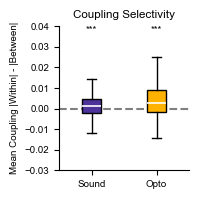

In [6]:
context = 'pre'
if context == 'passive':
    all_results = results_pass
else:
    all_results = results_pre
mode = 'mean'  #'mean' 'median'
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/' #f'V:/Connie/results/glm/2025/updated'
os.makedirs(save_results, exist_ok=True)

#initialize classes
plotter = plotterfun(data = None, save_results= save_results)
stats = GeneralStats()  # instantiate it
analysis_manager = analysisfun(data = None, plotter=plotter)

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_opto_vs_sound_coupling_{mode}_{context}.pdf', #'pooled_opto_vs_sound_coupling.pdf'
    mode = mode
)

quad_stats = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df,
    groups=['sound', 'opto'],
    save_dir=save_results,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90,
    colormap = 'viridis',
    string = context
)

p_value, observed_stat, permuted_stats = stats.permutation_test_quadrants(quad_stats['sound']['raw_counts'], quad_stats['opto']['raw_counts'], n_permutations=1000, seed=42) #stats['sound']['mean'].reshape(2,2)
print(f"Permutation test p-value: {p_value:.4g}, observed stat: {observed_stat:.3f}")

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{mode}_{context}.pdf')


# now look at absolute value of coupling betas
mode = 'mean_abs'  #'mean' 'median'

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_opto_vs_sound_coupling_{mode}_{context}.pdf',
    mode = mode
)

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{mode}_{context}.pdf')

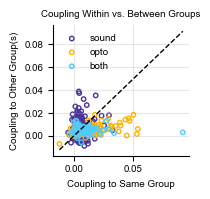

sound: p=0.3530, stat=0.000
opto: p=0.0002, stat=0.007
both: p=0.0006, stat=0.005
Bonferroni corrected alpha threshold: 0.01667
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


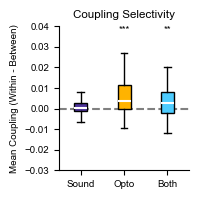

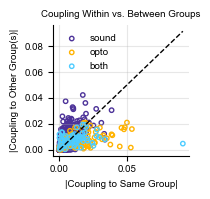

sound: p=0.0544, stat=-0.000
opto: p=0.0002, stat=0.008
both: p=0.0010, stat=0.004
Bonferroni corrected alpha threshold: 0.01667
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


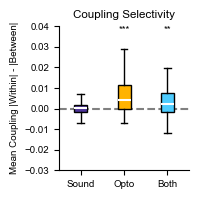

In [ ]:
# PLOTS INCLUDING UNMODULATED AND BOTH FUNCTIONAL GROUPS
all_results = results_pass
mode = 'mean'  #'mean' 'median'
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive/' #f'V:/Connie/results/glm/2025/updated'
os.makedirs(save_results, exist_ok=True)
groups_to_plot = ['sound','opto','both']#['sound','opto','both','unmod']
group_string = "_".join(groups_to_plot)

groups_to_plot2 = ['sound','opto','both']#['unmod','sound','opto','both']
group_string2 = "_".join(groups_to_plot2)


#initialize classes
plotter = plotterfun(data = None, save_results= save_results)
stats = GeneralStats()  # instantiate it
analysis_manager = analysisfun(data = None, plotter=plotter)

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = groups_to_plot2)

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_{group_string2}_coupling_{mode}.pdf', #'pooled_opto_vs_sound_coupling.pdf'
    mode = mode
)

# quad_stats = plotter.plot_quadrant_heatmap_across_datasets(
#     combined_df=coupling_df,
#     groups=groups_to_plot,
#     save_dir=save_results,
#     figsize=(2,2),
#     decimal_places=0,
#     vmax = 90,
#     colormap = 'viridis'
# )

# p_value, observed_stat, permuted_stats = stats.permutation_test_quadrants(quad_stats['sound']['raw_counts'], quad_stats['opto']['raw_counts'], n_permutations=1000, seed=42) #stats['sound']['mean'].reshape(2,2)
# print(f"Permutation test p-value: {p_value:.4g}, observed stat: {observed_stat:.3f}")

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = [g.capitalize() for g in groups_to_plot],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{group_string}_{mode}.pdf')


# now look at absolute value of coupling betas
mode = 'mean_abs'  #'mean' 'median'

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = groups_to_plot2)

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_{group_string2}_coupling_{mode}.pdf',
    mode = mode
)

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = [g.capitalize() for g in groups_to_plot],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{group_string}_{mode}.pdf')

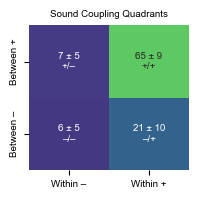

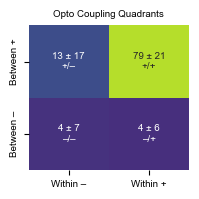

Chi-square test between sound and opto:
  χ² = 60.24, p = 5.219e-13, dof = 3
  Contingency Table:
       +/–   +/+  –/–  –/+
sound  112  1312   96  472
opto    27   214   10   10


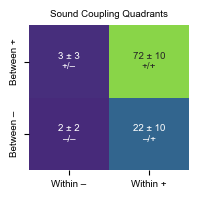

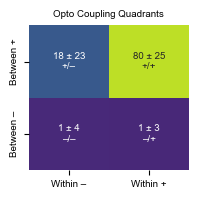

Chi-square test between sound and opto:
  χ² = 117.05, p = 3.328e-25, dof = 3
  Contingency Table:
       +/–   +/+  –/–  –/+
sound   44  1430   38  480
opto    28   227    3    3


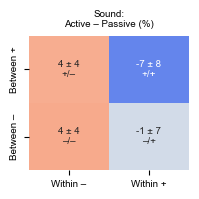

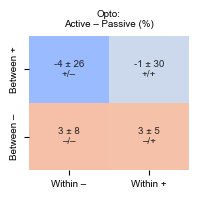

In [5]:
#COMPARING ACTIVE VS PASSIVE QUADRANTS
mode = 'mean'  #'mean' 'median'
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/' #f'V:/Connie/results/glm/2025/updated'
# os.makedirs(save_results, exist_ok=True)

coupling_df_pass = analysis_manager.wrapper_dataset_compute_within_between_coupling(results_pass,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])
coupling_df_act = analysis_manager.wrapper_dataset_compute_within_between_coupling(results_pre,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

quad_stats_act = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df_act,
    groups=['sound', 'opto'],
    save_dir=None,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90,
    colormap = 'viridis'
)

quad_stats_pass = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df_pass,
    groups=['sound', 'opto'],
    save_dir=None,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90,
    colormap = 'viridis'
)

quad_diff = plotter.plot_active_passive_quadrant_difference(
    quad_stats_active=quad_stats_act,
    quad_stats_passive=quad_stats_pass,
    vmax=10,
    figsize=(2,2),
    save_dir=save_results
)

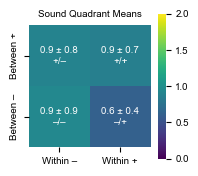

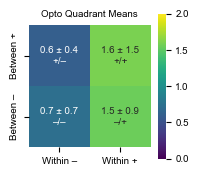

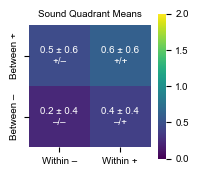

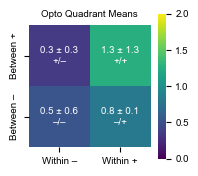

In [8]:
def plot_quadrant_means_across_datasets(
        combined_df,
        groups=('sound', 'opto'),
        dataset_col='dataset',
        group_col='group',
        save_dir=None,
        figsize=(3, 3),
        decimal_places=2,
        vmax=None,
        colormap='coolwarm',
        string=None,
        pool_across_datasets=False,
        metric='difference',   # 'within', 'between', or 'difference',
        scale_factor = 100
    ):

    mpl.rcParams['pdf.fonttype'] = 42
    plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})

    quadrant_labels = np.array([["+/–", "+/+"],
                                ["–/–", "–/+"]])

    all_group_stats = {}

    for group in groups:

        subset_group = combined_df[combined_df[group_col] == group]

        # function to compute metric of interest
        def get_metric(df):
            if metric == 'within':
                return df['coupling_within'].values
            elif metric == 'between':
                return df['coupling_between'].values
            elif metric == 'difference':
                return df['coupling_within'].values - df['coupling_between'].values 
            elif metric == 'distance':
                w = df['coupling_within'].values
                b = df['coupling_between'].values
                return np.sqrt(w**2 + b**2) * scale_factor
            else:
                raise ValueError("metric must be 'within', 'between','distance', or 'difference'")

        # helper to compute quadrant means for a dataframe
        def compute_quadrant_means(df):

            sign_within = np.sign(df['coupling_within'].values)
            sign_between = np.sign(df['coupling_between'].values)

            values = get_metric(df)

            quadrant_vals = { (0,0): [], (0,1): [], (1,0): [], (1,1): [] }

            for s_w, s_b, val in zip(sign_within, sign_between, values):

                row = 0 if s_b > 0 else 1
                col = 0 if s_w < 0 else 1

                quadrant_vals[(row, col)].append(val)

            means = np.zeros((2,2))
            stds = np.zeros((2,2))

            for (r,c), arr in quadrant_vals.items():
                if len(arr) > 0:
                    means[r,c] = np.nanmean(arr)
                    stds[r,c] = np.nanstd(arr)
                else:
                    means[r,c] = np.nan
                    stds[r,c] = np.nan

            return means, stds

        # ---- OPTION 1: POOL ALL NEURONS ----
        if pool_across_datasets:

            mean_matrix, std_matrix = compute_quadrant_means(subset_group)

            all_group_stats[group] = {
                'mean': mean_matrix,
                'std': std_matrix
            }

        # ---- OPTION 2: AVERAGE PER DATASET FIRST ----
        else:

            dataset_means = []
            for dataset in subset_group[dataset_col].unique():
                subset = subset_group[subset_group[dataset_col] == dataset]
                means, _ = compute_quadrant_means(subset)
                dataset_means.append(means)

            dataset_means = np.array(dataset_means)

            mean_matrix = np.nanmean(dataset_means, axis=0)
            std_matrix = np.nanstd(dataset_means, axis=0)

            all_group_stats[group] = {
                'mean': mean_matrix,
                'std': std_matrix,
                'all_dataset_means': dataset_means
            }

        # ----- PLOTTING -----

        label_matrix = np.array([
            [
                f"{mean_matrix[i,j]:.{decimal_places}f} ± {std_matrix[i,j]:.{decimal_places}f}\n{quadrant_labels[i,j]}"
                for j in range(2)
            ] for i in range(2)
        ])

        plt.figure(figsize=figsize)
        if metric == 'distance':
            center = None
            vmin=0
        else:
            center = 0
            vmin=-vmax if vmax else None

        sns.heatmap(
            mean_matrix,
            annot=label_matrix,
            fmt='',
            cmap=colormap,
            center=center,
            cbar=True,
            vmin=vmin,
            vmax=vmax,
            xticklabels=["Within –", "Within +"],
            yticklabels=["Between +", "Between –"]
        )

        mode = "pooled" if pool_across_datasets else "per dataset"

        plt.title(f'{group.capitalize()} Quadrant Means', fontsize=7) #\nMetric: {metric} ({mode})
        plt.tight_layout()
        ax = plt.gca()
        ax.set_box_aspect(1)

        if save_dir:
            tag = "_pooled" if pool_across_datasets else "_perDataset"
            if string:
                fname = f"{save_dir}/{group}_quadrant_means_{metric}_{string}{tag}.pdf"
            else:
                fname = f"{save_dir}/{group}_quadrant_means_{metric}{tag}.pdf"

            plt.savefig(fname, dpi=300)

        plt.show()

    return all_group_stats
import seaborn as sns
quadrant_means_act = plot_quadrant_means_across_datasets(combined_df= coupling_df_act,
    pool_across_datasets=True,
    metric='distance',
    figsize = (2,2),
    vmax = 2,
    colormap = 'viridis',
    decimal_places = 1
)

quadrant_means_pass = plot_quadrant_means_across_datasets(combined_df= coupling_df_pass,
    pool_across_datasets=True,
    metric='distance',
    figsize = (2,2),
    vmax = 2,
    colormap = 'viridis',
    decimal_places = 1
)


In [9]:
#UPDATE FUNCTIONS TO CALCULATE MEANS
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D

def calculate_coupling_index(mean_deviance_coupling, mean_deviance_uncoupled):
        """
        Calculate the coupling index.

        Parameters:
            mean_deviance_coupling (array_like): Deviance explained for the model with coupling predictors.
            mean_deviance_uncoupled (array_like): Deviance explained for the model without coupling predictors.

        Returns:
            np.ndarray: Coupling index for each observation.
        """
        # Ensure inputs are numpy arrays
        mean_deviance_coupling = np.array(mean_deviance_coupling)
        mean_deviance_uncoupled = np.array(mean_deviance_uncoupled)

        # Calculate the coupling index
        coupling_index = (mean_deviance_coupling - mean_deviance_uncoupled) / mean_deviance_coupling

        # Identify and handle cases with large coupling indices due to small or negative deviance values
        #extreme_indices = np.where((coupling_index > 1) & ((np.abs(mean_deviance_coupling) < threshold) | (np.abs(mean_deviance_uncoupled) < threshold)))
        #extreme_indices = np.where(mean_deviance_coupling < threshold)
        # extreme_indices = np.where(coupling_index > 1)
        # coupling_index[extreme_indices] = np.nan

        return coupling_index
def plot_coupling_index_across_celltypes_cdf(results_list, model_types, threshold=0.05, comparisons=[('No Coupling', 'All')], significant_neurons=None, xlim_val = 1, recalculate_modulation=False, figsize = (3*1.3,1.3*1.5)):
        """
        Plot the CDF of coupling index across datasets for multiple models, separated by cell type.

        Parameters:
            results_list (list of dict): List of results dictionaries for each model.
            celltypecolors (dict): Dictionary of colors for each cell type.
            save_results (str): Path to save the results.
            model_types (list of str): List of model types corresponding to each results dictionary.
            color_map_dict (dict): Dictionary mapping (celltype, model) to specific colors.
            threshold (float, optional): Threshold for filtering outlier values. Default is 1.
            comparisons (list of tuple of str, optional): List of comparison labels to use, e.g., [('No Coupling', 'All'), ('No Pyr', 'All')].
            significant_neurons (dict, optional): Dictionary with dataset keys mapping to lists of significant neuron indices.
            recalculate_modulation (bool, optional): If True, recalculate modulation index using neurons present across all comparisons and models.

        Returns:
            dict: Dictionary containing coupling indices by cell type and model for each comparison.
        """
        coupling_index_by_comparison = {}
        # Initialize a set to keep track of neuron indices used across all models 
        used_neurons_set = None
        # Initialize dictionary to track used neurons for each dataset
        used_neurons = {}  # To track used neurons for each comparison and model

        # Loop over each comparison
        for comparison in comparisons:
            # Initialize a dictionary to store coupling indices by cell type and model for the current comparison
            coupling_index_by_celltype = {
                'pyr': {model: [] for model in model_types},
                'som': {model: [] for model in model_types},
                'pv': {model: [] for model in model_types}
            }
            
            # Initialize used neurons set for this comparison
            used_neurons[comparison] = {model: set() for model in model_types}

            # Loop over each model's results
            for model_idx, results in enumerate(results_list):
                model_type = model_types[model_idx]
                

                # Initialize a dictionary to store the mean deviance explained values across all datasets
                mean_dev_dict = {
                    'No Coupling': [],
                    # 'All': [],
                    # 'No Pyr': [],
                    # 'No Som': [],
                    # 'No Pv': [],
                    'All Neurons': []
                }
                
                # Initialize a list to store all cell labels
                cell_labels = []
                
                # Loop over each dataset in the results dictionary
                for dataset_key, dataset in results.items():
                    # Get significant neurons for the dataset if provided
                    sig_neurons = significant_neurons.get(dataset_key, None) if significant_neurons else None
                    
                    # Filter data based on significant neurons if applicable
                    if sig_neurons is not None:
                        sig_neurons = np.array(sig_neurons[0], dtype=np.uint16)
                    else:
                        sig_neurons = np.arange(len(dataset['celltype_array']))  # Use all neurons if not specified

                    
                    # Filter mean deviance values
                    mean_dev_dict['No Coupling'].extend(np.array(dataset['mean_dev_0'])[sig_neurons]) #'mean_dev_behav'
                    # mean_dev_dict['All'].extend(np.array(dataset['mean_dev'])[sig_neurons])
                    # mean_dev_dict['No Pyr'].extend(np.array(dataset['mean_dev_no_pyr'])[sig_neurons])
                    # mean_dev_dict['No Som'].extend(np.array(dataset['mean_dev_no_som'])[sig_neurons])
                    # mean_dev_dict['No Pv'].extend(np.array(dataset['mean_dev_no_pv'])[sig_neurons])
                    mean_dev_dict['All Neurons'].extend(np.array(dataset['mean_dev_5'])[sig_neurons])
                    
                    # Map cell IDs to cell types and add to the cell_labels list
                    cell_types = {
                        0: 'pyr',
                        1: 'som',
                        2: 'pv',
                    }
                    cell_labels.extend([cell_types[cell_id] for cell_id in np.array(dataset['celltype_array'])[sig_neurons]])

                
                # Extract labels for the comparison
                label1, label2 = comparison
                
                # Identify outliers in the 'All' condition
                outlier_indices_all = np.where(np.array(mean_dev_dict['All Neurons']) < threshold)[0]


                # # Collect mean deviance values for outlier detection from the first model type
                # if model_idx == 0:  # Use only the first model's data for outlier detection
                #     all_mean_dev_all = np.array(mean_dev_dict['All'])

                # # Identify outliers in the 'All' condition based on the first model type
                # outlier_indices_all = np.where(all_mean_dev_all < threshold)[0]
                
                # Prepare data for comparison
                full_data = np.array(mean_dev_dict[label2]).astype(np.float64)
                partial_data = np.array(mean_dev_dict[label1]).astype(np.float64)

                # Mask outliers
                if len(outlier_indices_all) > 0:
                    #print(outlier_indices_all)
                    print(f'model type: {model_type}, original length, {len(full_data)}')
                    full_data[outlier_indices_all] = np.nan
                    partial_data[outlier_indices_all] = np.nan

                # Calculate coupling index
                coupling_index = calculate_coupling_index(full_data, partial_data) #analysisfun.calculate_coupling_index(full_data, partial_data)

                #eliminate coupling indices that are greater than one
                bad_coupling = np.where(coupling_index>1)
                coupling_index[bad_coupling] = np.nan

                bad_coupling = np.where(coupling_index<-1)
                coupling_index[bad_coupling] = np.nan

                # Update the used neurons for each dataset (non-NaN neurons) 
                valid_neurons = ~np.isnan(coupling_index) 
                used_neurons[comparison][model_type] = np.where(valid_neurons)[0]
                
                # Update the global used neurons set
                if used_neurons_set is None:
                    used_neurons_set = set(used_neurons[comparison][model_type])
                else:
                    used_neurons_set &= set(used_neurons[comparison][model_type])


                # Separate coupling index by cell type
                for idx, cell_label in enumerate(cell_labels):
                    coupling_index_by_celltype[cell_label][model_type].append(coupling_index[idx])

            # Store the results for the current comparison
            coupling_index_by_comparison[comparison] = coupling_index_by_celltype

        # Recalculate modulation index using only the neurons present across all comparisons and models if required
        if recalculate_modulation:
            print("Recalculating coupling index using neurons present across all comparisons and models...")


            # Initialize used_neurons_set for each cell type (to track common neurons across all comparisons and models)
            used_neurons_set_by_celltype = {
                'pyr': None,
                'som': None,
                'pv': None
            }

            # Iterate over all comparisons
            for comparison in comparisons:
                # Iterate over all model types
                for model_type in model_types:
                    # For each cell type, find non-NaN neuron indices and keep intersection across comparisons and models
                    for cell_type in used_neurons_set_by_celltype.keys():
                        # Get the coupling index array for the current comparison, model type, and cell type
                        neuron_data = np.array(coupling_index_by_comparison[comparison][cell_type][model_type]) #np.array(coupling_index_by_celltype[cell_type][model_type])
                        
                        # Identify non-NaN neuron indices
                        valid_neurons = np.where(~np.isnan(neuron_data))[0]
                    
                        # If this is the first time, initialize the set with valid neurons
                        if used_neurons_set_by_celltype[cell_type] is None:
                            used_neurons_set_by_celltype[cell_type] = set(valid_neurons)
                        else:
                            # Take intersection of valid neurons across models and comparisons
                            used_neurons_set_by_celltype[cell_type] = used_neurons_set_by_celltype[cell_type].intersection(valid_neurons)

            # Now used_neurons_set_by_celltype will contain only the neurons common across all comparisons and model types for each cell type
            # You can now check and print the number of non-NaN neurons across all comparisons and models

            for cell_type, neuron_set in used_neurons_set_by_celltype.items():
                print(f"Cell Type: {cell_type}, Number of common non-NaN neurons across all comparisons and models: {len(neuron_set)}")

            # Update coupling_index_by_comparison with the new common neurons
            for comparison in comparisons:
                for model_type in model_types:
                    for cell_type, neuron_set in used_neurons_set_by_celltype.items():
                        # Convert neuron set back to a list of indices for easy access
                        common_neurons_indices = np.array(list(neuron_set))
                        
                        # Loop through the neuron data for the current comparison, model type, and cell type
                        neuron_data = coupling_index_by_comparison[comparison][cell_type][model_type]
                        for idx, cell_label in enumerate(neuron_data):
                            # If the index is not in the common neuron set, mark it as NaN
                            if idx not in common_neurons_indices:
                                coupling_index_by_comparison[comparison][cell_type][model_type][idx] = np.nan

                        #CODE BELOW GIVES SAME NUMBER OF NEURONS IN EACH CONDITION (ie all active comparisons have the same BUT not across conditions)           
            # for comparison in comparisons:
            #     for cell_type in ['pyr', 'som', 'pv']:
            #         for model_type in model_types:
            #             # Filter out neurons not present in the global used_neurons_set
            #             neuron_indices = used_neurons_set.intersection(used_neurons[comparison][model_type])
            #             filtered_indices = np.array(list(neuron_indices))
            #             #print(f'{comparison} {cell_type} {model_type} total neurons {len(filtered_indices)}')

            #             for idx, cell_label in enumerate(coupling_index_by_comparison[comparison][cell_type][model_type]):
            #                 if idx not in filtered_indices:
            #                     coupling_index_by_comparison[comparison][cell_type][model_type][idx] = np.nan

        comparisons_list = []
        test_stats = []
        p_values = []
        all_stats_dict = {}

        for comparison in comparisons:
            label1, label2 = comparison
            # Paired permutation test for each cell type between model types
            for cell_type in plotter.celltypecolors.keys():
                print(f"\n{cell_type.upper()} Cell Type: {label1} vs {label2}")
                
                for model_a, model_b in zip(model_types[:-1], model_types[1:]):
                    data1 = np.array(coupling_index_by_comparison[comparison][cell_type][model_a]) # used to be coupling_index_by_celltype
                    data2 = np.array(coupling_index_by_comparison[comparison][cell_type][model_b])

                    # Perform paired permutation test
                    p_value, observed_diff= stats.perform_permutation_test(data1, data2, paired=True, n_permutations=10000)#paired_permutation_test(data1, data2)

                    print(f"Model {model_a} vs {model_b}:")
                    print(f"Observed Difference: {observed_diff:.4f}, P-value: {p_value:.4f}")

                    comparisons_list.append((f"{comparison}_{cell_type}_{model_a}", f"{comparison}_{cell_type}_{model_b}"))
                    test_stats.append(observed_diff)
                    p_values.append(p_value)

                    # Save stats for each group
                    label1_stats = f"{comparison}_{cell_type}_{model_a}"
                    label2_stats = f"{comparison}_{cell_type}_{model_b}"
                    all_stats_dict[label1_stats] = stats.get_basic_stats(data1)
                    all_stats_dict[label2_stats] =stats.get_basic_stats(data2)


            # Plot the CDF of coupling index for each cell type for the current comparison
            # Set global font size and family 
            plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})
            plt.figure(figsize=figsize )

            for i, (celltype, _) in enumerate(plotter.celltypecolors.items()):
                ax = plt.subplot(1, 3, i+1)
                
                legend_elements = []

                # Plot the CDF for each model within the current cell type
                for model_type in model_types:

                    sorted_data = np.sort(coupling_index_by_comparison[comparison][celltype][model_type]) #coupling_index_by_celltype
                    print(f'model type: {model_type}, {celltype},{len(sorted_data)}, original length, {len(full_data)}')
                    x1 = np.linspace(0, 1, 100)  # Define range of x values
                    n1, _ = np.histogram(sorted_data, bins=x1)  # Histogram counts
                    p1 = n1 / np.sum(n1)  # Probability
                    cdf = np.cumsum(p1)  # Cumulative sum to get CDF
                    
                    # Use color_map_dict to assign the specific color
                    print(f'celltype {celltype} model_type {model_type}')
                    plt.plot(x1[:-1], cdf, label=f'{model_type}', color=plotter.color_map_dict[(celltype, model_type)], linewidth=1)

                    legend_elements.append(Line2D([0], [0], color=plotter.color_map_dict[(celltype, model_type)], lw=2, label=model_type))

                # Set the title and labels for the plot
                if comparison[0] == 'No Coupling':
                    label_str = list({celltype})[0].upper()  # → 'PYR'
                    plt.title(label_str )
                else:
                    plt.title(f'{label1} vs {label2}') #{celltype} -
                plt.xlabel('Coupling Index')
                if i == 0:
                    plt.ylabel('Cumulative Fraction')

                # Define the ticks you want (e.g., from 0 to 1 with increments of 0.1)
                ticks = np.arange(0, 1.1, 0.2)  # The 1.1 ensures that 1.0 is included in the ticks

                # Set the format for both x and y axis ticks to show one decimal place
                plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                plt.xticks(rotation=45)  # Rotates labels 45 degrees

                plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
                # Ensure ticks are from 0 to 1 with consistent intervals
                plt.xticks(np.arange(0, 1.2, 0.2))
                plt.yticks(np.arange(0, 1.2, 0.2))

                # Custom legend
                # Add legend with colored labels
                legend = ax.legend(handles=legend_elements, frameon=False, loc='best', handlelength=0, handletextpad=0.1)

                # Set the color of the legend text to match the corresponding model types
                for text in legend.get_texts():
                    # Extract the model type from the legend entry
                    model_type = text.get_text()
                    # Retrieve the color from color_map_dict using the current cell type and model type
                    color =plotter.color_map_dict.get((celltype, model_type), 'black')
                    text.set_color(color)

                # Clean up the appearance
                ax = plt.gca()
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.set_box_aspect(1)
                ax.set_xlim(0, xlim_val)
                ax.set_ylim(0, 1)

            #to save svg so that we can edit texts!
            new_rc_params = {'text.usetex': False,
            "svg.fonttype": 'none'
            }
            plt.rcParams.update(new_rc_params)

            # Save the figure for the current comparison
            plt.tight_layout()
            if significant_neurons is not None:
                save_string = f'cdf_coupling_index_comparison_{label1}_vs_{label2}_by_celltype_sigcells.png'
                save_string = f'cdf_coupling_index_comparison_{label1}_vs_{label2}_by_celltype_sigcells.pdf'
                # save_string = f'cdf_coupling_index_comparison_{label1}_vs_{label2}_by_celltype_sigcells.pdf'
            else:
                save_string = f'cdf_coupling_index_comparison_{label1}_vs_{label2}_by_celltype_{model_types}.png'
                save_string = f'cdf_coupling_index_comparison_{label1}_vs_{label2}_by_celltype_{model_types}.pdf'
                # save_string = f'cdf_coupling_index_comparison_{label1}_vs_{label2}_by_celltype.pdf'
            plt.savefig(os.path.join(plotter.save_results, save_string),bbox_inches='tight', dpi=300, transparent=True)
            plt.show()

        # Save statistical test results to table
        save_path = os.path.join(plotter.save_results)
        df_tests = stats.to_table(comparisons_list, test_stats, p_values, save_path=f'{save_path}/stat_tests_coupling_index.csv', type='permutation')
        df_stats = stats.basic_stats_to_table(all_stats_dict, save_path=f'{save_path}/basic_stats_coupling_index.csv')

        return coupling_index_by_comparison, used_neurons

model type: Active, original length, 7545
model type: Passive, original length, 7545
Recalculating coupling index using neurons present across all comparisons and models...
Cell Type: pyr, Number of common non-NaN neurons across all comparisons and models: 1155
Cell Type: som, Number of common non-NaN neurons across all comparisons and models: 98
Cell Type: pv, Number of common non-NaN neurons across all comparisons and models: 286

PYR Cell Type: No Coupling vs All Neurons


c:\Users\runyan1\AppData\Local\anaconda3\envs\Python_GLM\Lib\site-packages\scipy\stats\_resampling.py:1114: RuntimeWarning: overflow encountered in double_scalars
  n_max = factorial(n_obs_sample)**n_samples


Model Active vs Passive:
Observed Difference: nan, P-value: 0.0002

SOM Cell Type: No Coupling vs All Neurons
Model Active vs Passive:
Observed Difference: nan, P-value: 0.0002

PV Cell Type: No Coupling vs All Neurons
Model Active vs Passive:
Observed Difference: nan, P-value: 0.0002
model type: Active, pyr,6455, original length, 7545
celltype pyr model_type Active
model type: Passive, pyr,6455, original length, 7545
celltype pyr model_type Passive
model type: Active, som,352, original length, 7545
celltype som model_type Active
model type: Passive, som,352, original length, 7545
celltype som model_type Passive
model type: Active, pv,738, original length, 7545
celltype pv model_type Active
model type: Passive, pv,738, original length, 7545
celltype pv model_type Passive


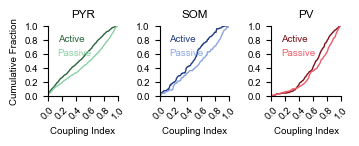

In [10]:
# COMPUTE COUPLING INDEX NOW USING THE ALL COUPLED VS BEHAVIOR ONLY MODELS
results_list = [results_pre,results_pass]

model_types = [ 'Active', 'Passive'] #['Active Task', 'Active ITI', 'Passive']

comparisons = [('No Coupling','All Neurons')]
color_map_dict = {('pyr', 'Active'): '#29663C', ('pyr', 'Active ITI'): '#3A9256', ('pyr', 'Passive'): '#8AD0A2',
                   ('som', 'Active'): '#203C83', ('som', 'Active ITI'): '#3A64CF', ('som', 'Passive'): '#8CA5E3', 
                   ('pv', 'Active'): '#7F1019', ('pv', 'Active ITI'): '#C81927', ('pv', 'Passive'): '#EB5C68'}
plotter_context = plotterfun(data = None,celltypecolors=plotter.celltypecolors, save_results= save_results, color_map_dict =  color_map_dict)
analysis_manager = analysisfun(data = None, plotter=plotter_context)
plotter.save_results = 'W:\Connie/results\Bassi2025\glm_coupling\supplement'
plotter.color_map_dict = color_map_dict
coupling_index_by_celltype,_ = plot_coupling_index_across_celltypes_cdf(results_list,  #analysis_manager.
         model_types, comparisons=comparisons,recalculate_modulation= True, figsize = (3*1.2,1.2*1.5)) #figsize = (3*1.3,1.3*1.5)

In [13]:
results_pre['HA1-00_2023-06-27']['mean_dev_0']

array([ 2.54877876e-02,  1.78401372e-02,  1.86269230e-01,  2.52711259e-02,
        1.42917403e-02,  5.05816090e-02,  8.74773504e-02,  5.15110342e-02,
       -4.31964133e-04,  4.74455913e-02,  6.98818683e-02, -1.67198944e-04,
        7.10349503e-02,  4.15956249e-03, -2.26972525e-03,  1.51565625e-02,
        3.97120529e-03, -1.74379405e-03,  3.35684545e-03,  1.06664643e-02,
        2.89719622e-03,  4.96264199e-02, -1.30103038e-03,  1.61721330e-01,
        4.37426614e-02,  7.24695848e-03,  1.12113608e-02,  9.32708510e-02,
        6.40805326e-02,  1.91569737e-01,  7.15215315e-03,  5.60387366e-02,
       -6.17202945e-04,  6.91463711e-02,  1.31762809e-01,  8.34258320e-02,
        2.37528589e-03,  3.07140989e-02,  1.62562263e-01,  2.01539936e-01,
        4.67879761e-02,  2.48811981e-04,  1.12452369e-01,  2.76425445e-02,
        9.91583812e-02,  1.78748173e-01,  9.33825440e-02,  7.87384787e-04,
        6.14391556e-02,  4.73963691e-02,  5.83999796e-02, -1.62166197e-02,
        1.47152623e-02,  

Found 2 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 2 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
_0 model deviance explained: 0.076 ± 0.094
Found 2 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]


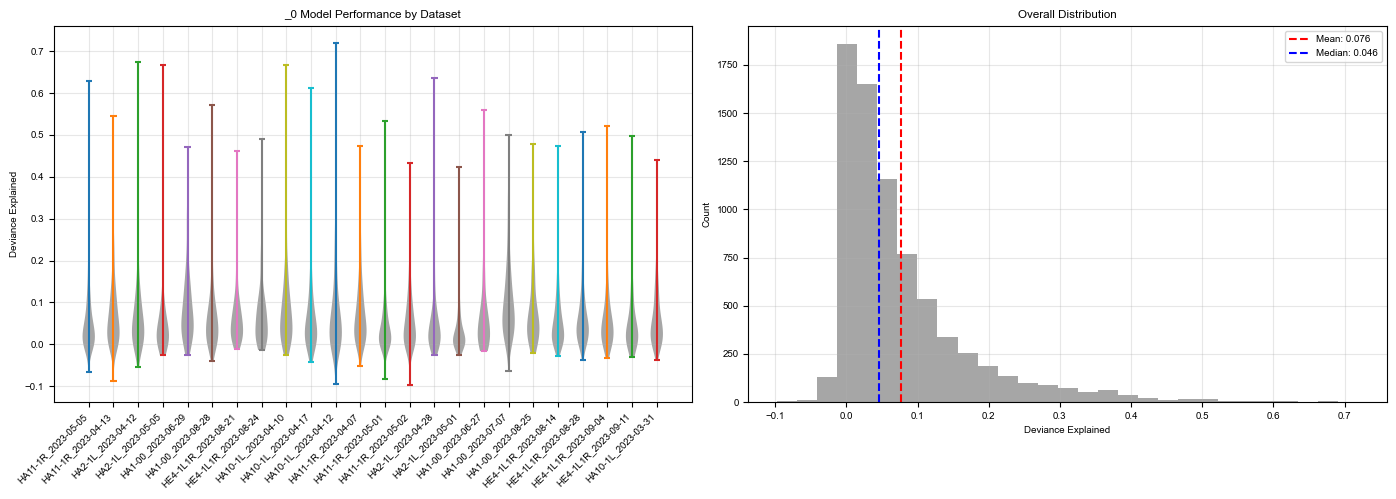

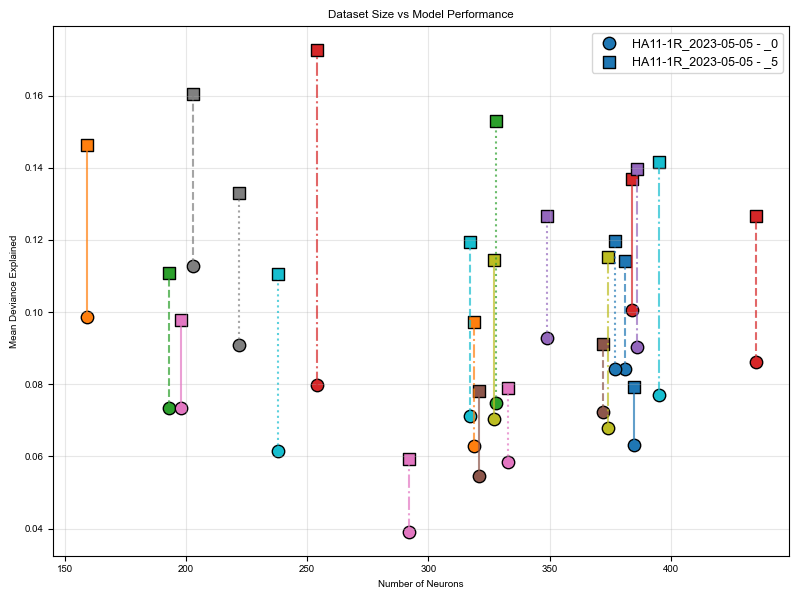

Found 5 outliers with values outside [-0.2, 1]
Found 6 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 4 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 7 outliers with values outside [-0.2, 1]
Found 5 outliers with values outside [-0.2, 1]
Found 5 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 7 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 3 outliers with values outside [-0.2, 1]
Found 4 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 14 outliers with values outside [-0.2, 1]


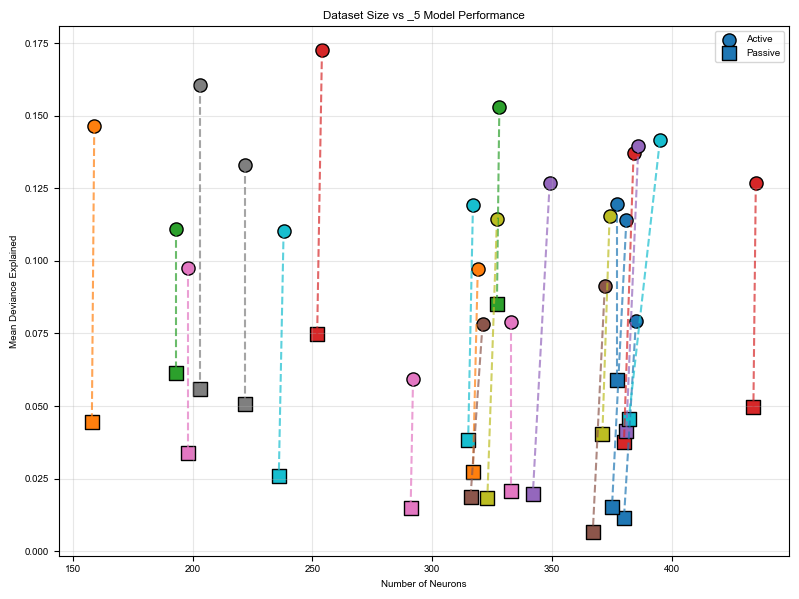

In [23]:
#check variance explained across datasets (since they have different number of neurons!)
# Create output directory for supplemental figures
supp_figure_dir = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/' 
os.makedirs(supp_figure_dir, exist_ok=True)
import matplotlib.pyplot as plt


def clean_deviance_values(dev_values, lower_bound=-1, upper_bound=1):
    """Clean deviance explained values by removing extreme outliers."""
    cleaned_dev = np.array(dev_values, dtype=float)
    
    # Find extreme outliers
    outliers = np.where((cleaned_dev < lower_bound) | (cleaned_dev > upper_bound))[0]
    if len(outliers) > 0:
        print(f"Found {len(outliers)} outliers with values outside [{lower_bound}, {upper_bound}]")
        cleaned_dev[outliers] = np.nan
    
    return cleaned_dev

def plot_deviance_summary(results_pre, model_type='behav', save_path=None, 
                         lower_bound=-.2, upper_bound=1):
    """Plot deviance explained summary across datasets."""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Collect deviance explained for all datasets
    dataset_dev = []
    dataset_labels = []
    all_dev = []
    dataset_mean_dict = {}   # <-- ADD THIS
    
    for dataset in results_pre.keys():
        dev_key = f'mean_dev{model_type}'
        # Clean deviance values
        dev_explained = clean_deviance_values(
            results_pre[dataset][dev_key],
            lower_bound=lower_bound,
            upper_bound=upper_bound
        )
        all_dev.extend(dev_explained[~np.isnan(dev_explained)])
        
        dataset_dev.append(np.nanmean(dev_explained))
        dataset_labels.append(dataset)
        dataset_mean = np.nanmean(dev_explained)
        dataset_mean_dict[dataset] = dataset_mean   # <-- STORE IT
        
        # Plot distribution for each dataset
        valid_dev = dev_explained[~np.isnan(dev_explained)]
        violin = ax1.violinplot(valid_dev, positions=[len(dataset_dev)-1])
        for pc in violin['bodies']:
            pc.set_facecolor('gray')
            pc.set_alpha(0.7)
    
    # Customize dataset distribution plot
    ax1.set_xticks(range(len(dataset_labels)))
    ax1.set_xticklabels(dataset_labels, rotation=45, ha='right')
    ax1.set_ylabel('Deviance Explained')
    ax1.set_title(f'{model_type.capitalize()} Model Performance by Dataset')
    ax1.grid(True, alpha=0.3)
    
    # Plot overall distribution
    bins = np.linspace(np.nanmin(all_dev), np.nanmax(all_dev), 30)
    ax2.hist(all_dev, bins=bins, color='gray', alpha=0.7)
    ax2.axvline(np.nanmean(all_dev), color='r', linestyle='--', 
                label=f'Mean: {np.nanmean(all_dev):.3f}')
    ax2.axvline(np.nanmedian(all_dev), color='b', linestyle='--', 
                label=f'Median: {np.nanmedian(all_dev):.3f}')
    ax2.set_xlabel('Deviance Explained')
    ax2.set_ylabel('Count')
    ax2.set_title('Overall Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    return np.nanmean(all_dev), np.nanstd(all_dev), dataset_mean_dict


def plot_deviance_summary_single_plot(results_pre, model_type='behav', save_path=None, 
                         lower_bound=-.2, upper_bound=1, figsize=(14, 5), bins = 30, ylims=(0,50), label_names=True, color_hist = 'gray',ax2=None):
    """Plot deviance explained summary across datasets."""
    if ax2 is None:
        fig, (ax2) = plt.subplots(1, figsize=figsize)
    # Set global font size and family 
    plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})
    
    # Collect deviance explained for all datasets
    dataset_dev = []
    dataset_labels = []
    all_dev = []
    
    for dataset in results_pre.keys():
        dev_key = f'mean_dev{model_type}'
        # Clean deviance values
        dev_explained = clean_deviance_values(
            results_pre[dataset][dev_key],
            lower_bound=lower_bound,
            upper_bound=upper_bound
        )
        all_dev.extend(dev_explained[~np.isnan(dev_explained)])
        
        dataset_dev.append(np.nanmean(dev_explained))
        dataset_labels.append(dataset)
        
    
    # Plot overall distribution
    bins = np.linspace(np.nanmin(all_dev), np.nanmax(all_dev), bins)
    # ax2.hist(all_dev, bins=bins, color='gray', alpha=0.7)
    # Plot overall distribution as percentage histogram
    counts, bins = np.histogram(all_dev, bins= bins)  # raw counts
    percentages = counts / len(all_dev) * 100      # convert to %

    ax2.bar(bins[:-1], percentages, width=np.diff(bins),
            color= color_hist, alpha=0.7, align='edge')
    
    default_color_mean = 'black' #'orangered'
    default_color_median = 'orangered' ##'mediumblue'
    ax2.axvline(np.nanmean(all_dev), color=default_color_mean, linestyle='--', 
                label=f'Mean: {np.nanmean(all_dev):.3f}')
    ax2.axvline(np.nanmedian(all_dev), color=default_color_median, linestyle='--', 
                label=f'Median: {np.nanmedian(all_dev):.3f}')
    if label_names:
        ax2.set_xlabel('Deviance Explained')
        ax2.set_ylabel("Probability (%)")
    # ax2.set_ylabel('Count')
    # Update y-axis to percentage
    # ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))


    # ax2.set_title('Overall Distribution')
    # ax2.legend(loc = 'upper right', fontsize=6) #loc='center left', bbox_to_anchor=(1, 0.5)
    ax2.legend(
        loc="upper right",
        bbox_to_anchor=(1.5, 1),  # push legend to the right
        fontsize=6,
        frameon=False
    )

    # ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6) #loc='center left', bbox_to_anchor=(1, 0.5)
    # ax2.grid(True, alpha=0.3)

    if ylims:
        ax2.set_ylim(ylims)
    xlims = (-.1,.5)
    ax2.set_xlim(xlims)

    for spine in ["top", "right"]:
        ax2.spines[spine].set_visible(False)

    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    return np.nanmean(all_dev), np.nanstd(all_dev)

import numpy as np
import matplotlib.pyplot as plt

def plot_neurons_vs_mean_deviance(results_pre,
                                  model_types=('behav',),
                                  lower_bound=-.2,
                                  upper_bound=1):
    """
    Scatter plot: number of neurons vs mean deviance per dataset.
    
    Parameters
    ----------
    results_pre : dict
        Structure:
        results_pre[dataset][f'mean_dev{model_type}'] -> array (#neurons,)
    model_types : tuple or list
        One or more model types (e.g. ('behav', 'coupling'))
    lower_bound, upper_bound : float
        Bounds for deviance cleaning
    """
    
    if isinstance(model_types, str):
        model_types = (model_types,)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    datasets = list(results_pre.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))
    
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
    linestyles = ['-', '--', ':', '-.']
    
    for d_idx, dataset in enumerate(datasets):
        dataset_color = colors[d_idx]
        
        neuron_counts = []
        mean_devs = []
        
        for m_idx, model_type in enumerate(model_types):
            dev_key = f'mean_dev{model_type}'
            
            dev_explained = clean_deviance_values(
                results_pre[dataset][dev_key],
                lower_bound=lower_bound,
                upper_bound=upper_bound
            )
            
            valid_dev = dev_explained[~np.isnan(dev_explained)]
            
            n_neurons = len(valid_dev)
            mean_dev = np.nanmean(valid_dev)
            
            neuron_counts.append(n_neurons)
            mean_devs.append(mean_dev)
            
            # Scatter point
            ax.scatter(
                n_neurons,
                mean_dev,
                color=dataset_color,
                marker=markers[m_idx % len(markers)],
                s=80,
                edgecolor='black',
                label=f'{dataset} - {model_type}' if d_idx == 0 else ""
            )
        
        # Connect models within dataset
        if len(model_types) > 1:
            ax.plot(
                neuron_counts,
                mean_devs,
                color=dataset_color,
                linestyle=linestyles[d_idx % len(linestyles)],
                alpha=0.7
            )
    
    ax.set_xlabel('Number of Neurons')
    ax.set_ylabel('Mean Deviance Explained')
    ax.set_title('Dataset Size vs Model Performance')
    ax.grid(True, alpha=0.3)
    
    # Clean legend (only model labels once)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=9)
    
    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_neurons_vs_mean_deviance_multiple(results_1,
                                  results_2=None,
                                  model_type='behav',
                                  label_1='Model 1',
                                  label_2='Model 2',
                                  lower_bound=-.2,
                                  upper_bound=1):
    """
    Scatter plot: # neurons vs mean deviance per dataset.
    Optionally compares two model result dictionaries.
    
    Parameters
    ----------
    results_1 : dict
    results_2 : dict or None
    model_type : str
        e.g. 'behav'
    label_1, label_2 : str
        Labels for legend
    """
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    datasets = list(results_1.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))
    
    marker_1 = 'o'
    marker_2 = 's'
    
    for d_idx, dataset in enumerate(datasets):
        dataset_color = colors[d_idx]
        dev_key = f'mean_dev{model_type}'
        
        # ----- MODEL 1 -----
        dev1 = clean_deviance_values(
            results_1[dataset][dev_key],
            lower_bound=lower_bound,
            upper_bound=upper_bound
        )
        valid1 = dev1[~np.isnan(dev1)]
        
        n1 = len(valid1)
        mean1 = np.nanmean(valid1)
        
        ax.scatter(
            n1,
            mean1,
            color=dataset_color,
            marker=marker_1,
            s=90,
            edgecolor='black',
            label=label_1 if d_idx == 0 else ""
        )
        
        # ----- MODEL 2 (OPTIONAL) -----
        if results_2 is not None:
            
            dev2 = clean_deviance_values(
                results_2[dataset][dev_key],
                lower_bound=lower_bound,
                upper_bound=upper_bound
            )
            valid2 = dev2[~np.isnan(dev2)]
            
            n2 = len(valid2)
            mean2 = np.nanmean(valid2)
            
            ax.scatter(
                n2,
                mean2,
                color=dataset_color,
                marker=marker_2,
                s=90,
                edgecolor='black',
                label=label_2 if d_idx == 0 else ""
            )
            
            # Connect the two models within dataset
            ax.plot(
                [n1, n2],
                [mean1, mean2],
                color=dataset_color,
                linestyle='--',
                alpha=0.7
            )
    
    ax.set_xlabel('Number of Neurons')
    ax.set_ylabel('Mean Deviance Explained')
    ax.set_title(f'Dataset Size vs {model_type.capitalize()} Model Performance')
    ax.grid(True, alpha=0.3)
    
    ax.legend()
    plt.savefig('W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/act_pass_dev_vs_cellcount.pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()


# Usage remains the same
model_types = ['_0']
dev_stats = {}

for model in model_types:
    mean_dev, std_dev, dataset_mean_dict = plot_deviance_summary(
        results_pre,
        model_type=model,
        save_path=f'{supp_figure_dir}/deviance_explained_{model}.pdf',
        lower_bound=-.1,  # Adjust these bounds as needed
        upper_bound=1
    )
    dev_stats[model] = {'mean': mean_dev, 'std': std_dev}
    print(f"{model.capitalize()} model deviance explained: {mean_dev:.3f} ± {std_dev:.3f}")


#second plot
plot_neurons_vs_mean_deviance(results_pre,
                              model_types=('_0','_5'))

plot_neurons_vs_mean_deviance_multiple(results_pre,
                              results_pass,
                              model_type='_5',
                              label_1='Active',
                              label_2='Passive')



Found 5 outliers with values outside [-0.2, 1]
Found 6 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 4 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 7 outliers with values outside [-0.2, 1]
Found 5 outliers with values outside [-0.2, 1]
Found 5 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 7 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 3 outliers with values outside [-0.2, 1]
Found 4 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 2 outliers with values outside [-0.2, 1]
Found 1 outliers with values outside [-0.2, 1]
Found 14 outliers with values outside [-0.2, 1]


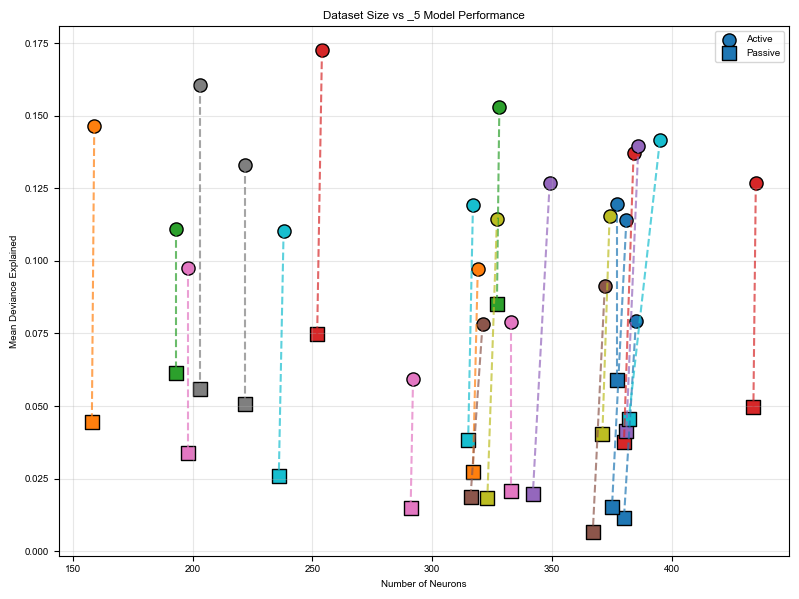

In [22]:
plot_neurons_vs_mean_deviance_multiple(results_pre,
                              results_pass,
                              model_type='_5',
                              label_1='Active',
                              label_2='Passive')



In [ ]:
#TO CHECK IF ALL DATASETS LOADED PROPERLY
# del results_pass['HA2-1L_2023-04-28']
for dataset in results_pre:
    print(dataset)

    ex = {}
    ex[dataset] = results_pre[dataset]

    coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(
        ex,
        significant_neurons,
        mode=mode,
        groups_to_plot=['sound', 'opto']
    )


HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-09-04
HE4-1L1R_2023-09-11
